In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../../notebooks/_elena/data/bcn_noise_regre_ml_dataset_filtered.csv').dropna()

drop_cols = [c for c in ['road_id', 'noise_day', 'noise_evening', 'noise_night'] if c in df.columns]
X = df.drop(columns=drop_cols).values
scaler = StandardScaler()

PERIODS = ['day', 'evening', 'night']
COLORS  = {'day': '#d58430', 'evening': '#7251ce', 'night': '#144849'}

MODELS = {
    'Linear Regression': LinearRegression(),
    'XGBoost':           xgb.XGBRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(random_state=42, n_jobs=-1),
}

# Train each model on each period and collect both train and test predictions
results = {}  # results[model_name][period] = (y_tr, y_pred_tr, y_te, y_pred_te)
for model_name, model in MODELS.items():
    results[model_name] = {}
    for period in PERIODS:
        y = df[f'noise_{period}'].values
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        model.fit(X_tr_s, y_tr)
        y_pred_tr = model.predict(X_tr_s)
        y_pred_te = model.predict(X_te_s)
        results[model_name][period] = (y_tr, y_pred_tr, y_te, y_pred_te)
    print(f'{model_name} done')

Linear Regression done
XGBoost done
Random Forest done


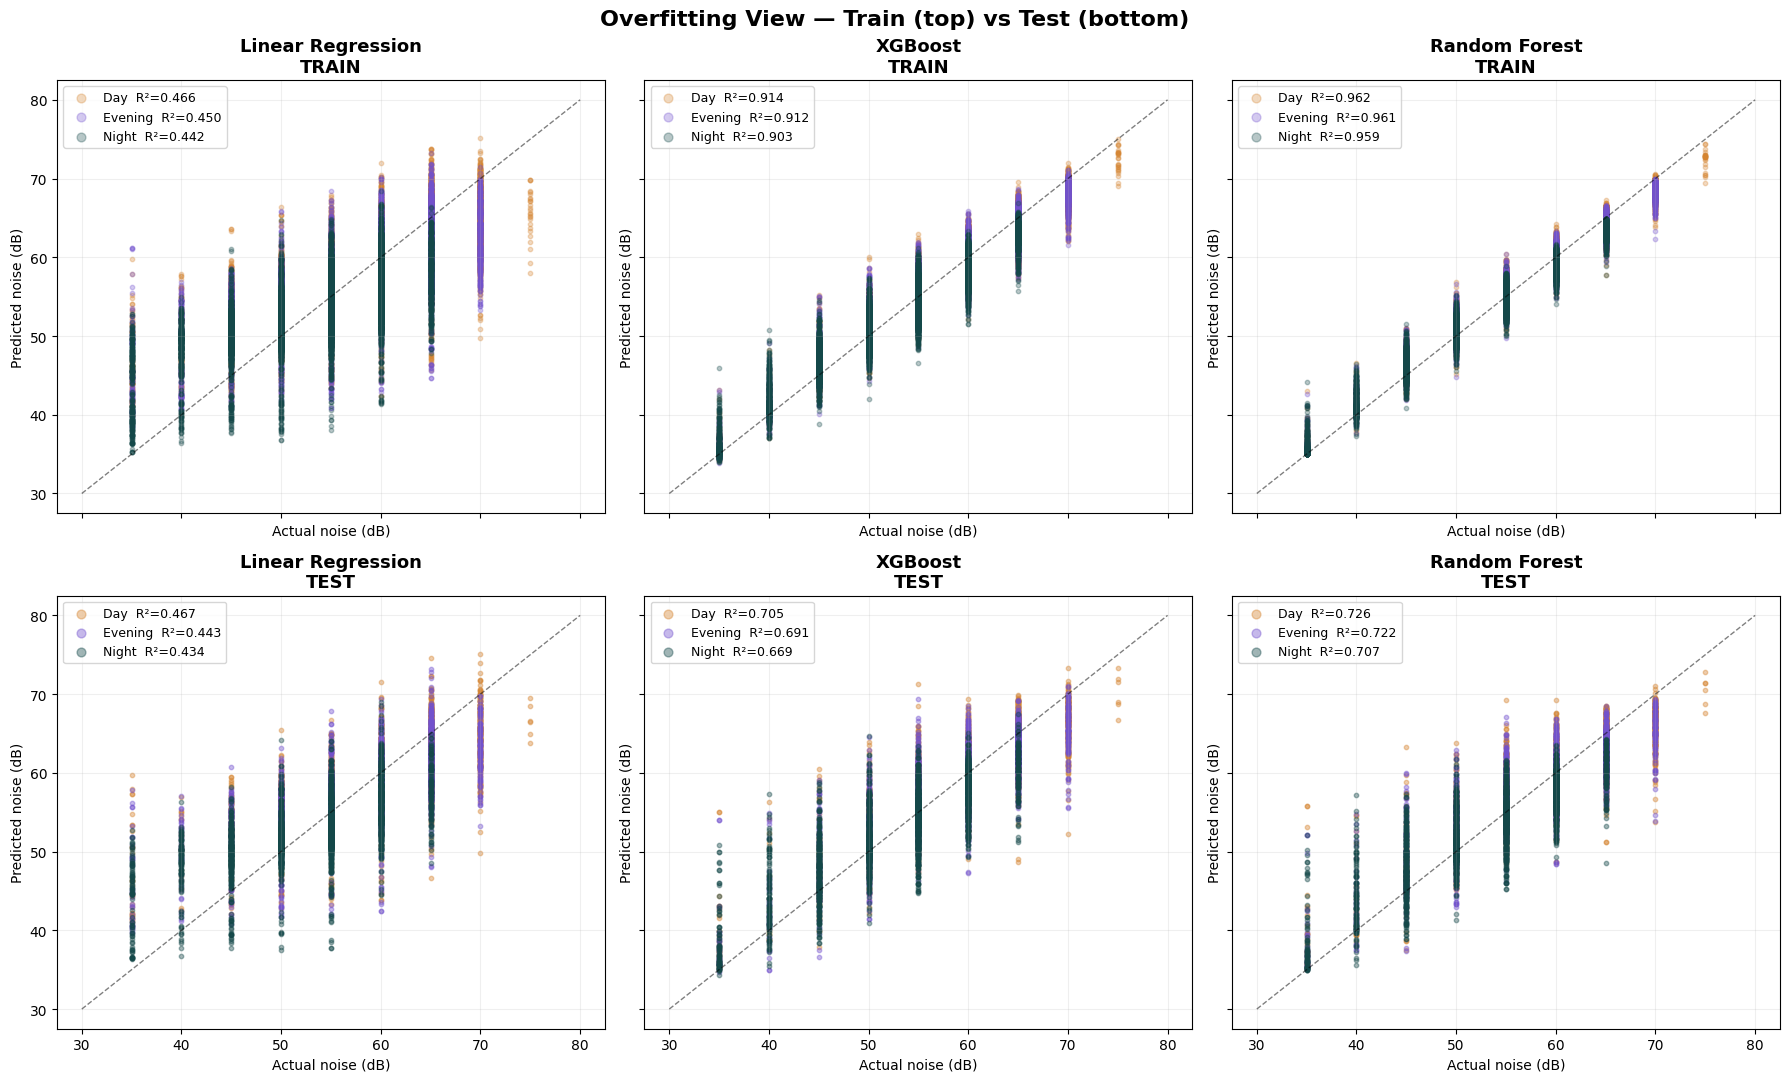

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharex=True, sharey=True)

for col, (model_name, period_results) in enumerate(results.items()):
    ax_tr = axes[0, col]
    ax_te = axes[1, col]

    for period in PERIODS:
        y_tr, y_pred_tr, y_te, y_pred_te = period_results[period]
        r2_tr = r2_score(y_tr, y_pred_tr)
        r2_te = r2_score(y_te, y_pred_te)
        color = COLORS[period]

        ax_tr.scatter(y_tr, y_pred_tr, color=color, alpha=0.3, s=10,
                      label=f'{period.capitalize()}  R²={r2_tr:.3f}')
        ax_te.scatter(y_te, y_pred_te, color=color, alpha=0.4, s=10,
                      label=f'{period.capitalize()}  R²={r2_te:.3f}')

    for ax in (ax_tr, ax_te):
        lo, hi = 30, 80
        ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5)
        ax.set_xlabel('Actual noise (dB)', fontsize=10)
        ax.set_ylabel('Predicted noise (dB)', fontsize=10)
        ax.legend(fontsize=9, markerscale=2)
        ax.grid(True, alpha=0.2)

    ax_tr.set_title(f'{model_name}\nTRAIN', fontsize=13, fontweight='bold')
    ax_te.set_title(f'{model_name}\nTEST', fontsize=13, fontweight='bold')

fig.suptitle('Overfitting View — Train (top) vs Test (bottom)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../../figures/model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

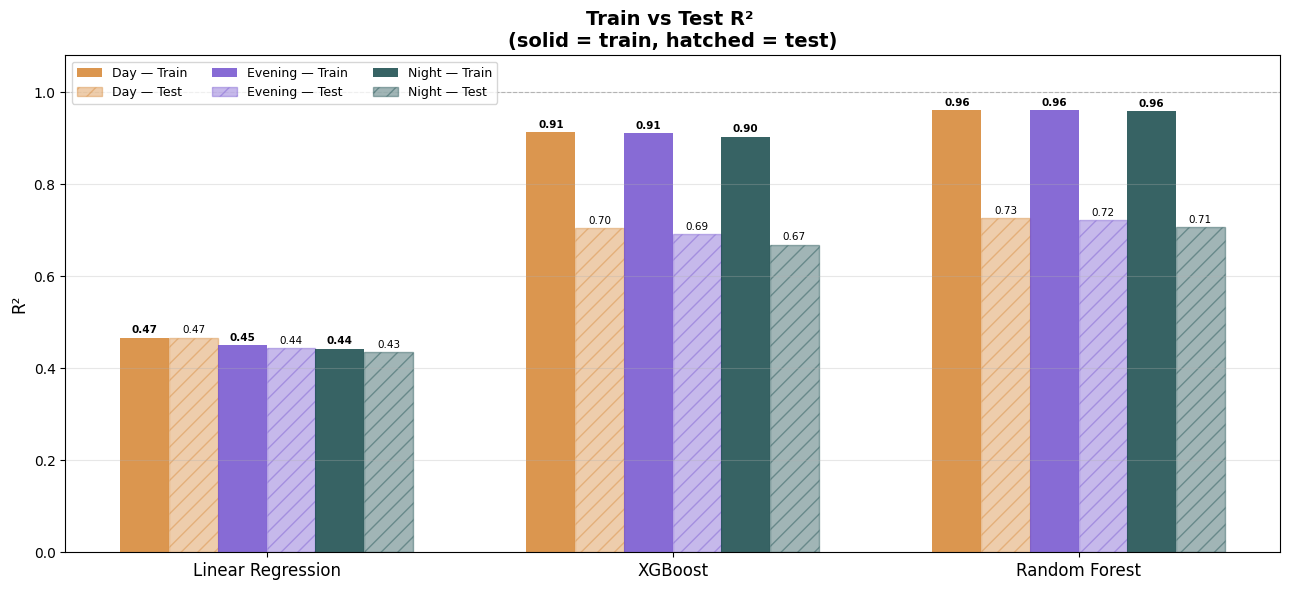

In [4]:
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.12
period_offsets = {'day': -1, 'evening': 0, 'night': 1}

fig, ax = plt.subplots(figsize=(13, 6))

for period, offset in period_offsets.items():
    r2_trains = [r2_score(results[m][period][0], results[m][period][1]) for m in model_names]
    r2_tests  = [r2_score(results[m][period][2], results[m][period][3]) for m in model_names]

    pos_tr = x + offset * width * 2 - width * 0.5
    pos_te = x + offset * width * 2 + width * 0.5

    bars_tr = ax.bar(pos_tr, r2_trains, width, color=COLORS[period], alpha=0.85,
                     label=f'{period.capitalize()} — Train')
    bars_te = ax.bar(pos_te, r2_tests,  width, color=COLORS[period], alpha=0.4,
                     hatch='//', edgecolor=COLORS[period],
                     label=f'{period.capitalize()} — Test')

    for bar, val in zip(bars_tr, r2_trains):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    for bar, val in zip(bars_te, r2_tests):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_ylim(0, 1.08)
ax.axhline(1.0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Train vs Test R² \n(solid = train, hatched = test)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, ncol=3, loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../figures/model_comparison_overfitting.png', dpi=200, bbox_inches='tight')
plt.show()